# OECD Country Risk Rating — Project Summary

**Author:** Hippolyte Grandet · MSc Artificial Intelligence, University of Edinburgh

---

## What this project does

OECD country risk ratings (scale 1–7, where 1 = highest risk) are produced by expert committees as sovereign creditworthiness assessments. This project asks a focused question:

> **How well can publicly available macroeconomic data reproduce expert risk assessments?**

Using 94 World Bank indicators across 181 countries (1999–2024), we build a machine learning pipeline that predicts these ratings under strict temporal constraints — training only on past data, testing only on future years.

---

## Pipeline at a glance

```
World Bank API  ──►  94 macro indicators
OECD PDF        ──►  risk ratings (target)
                        │
                        ▼
             Merge by country × year
                        │
                        ▼
  Feature selection  (missingness · variance · correlation)
  Feature engineering (ENG_* composite indicators)
                        │
                        ▼
  Temporal split: train 1999–2020 · test 2021–2024
  sklearn preprocessing pipeline (impute · scale · encode)
                        │
                        ▼
  Model training + MLflow tracking
```

---

## Key results

| Model | Macro F1 | Accuracy | Blurred Acc. (±1) |
|---|---|---|---|
| Logistic Regression (baseline) | 0.604 | 0.711 | — |
| XGBoost Regressor | 0.487 | 0.560 | 0.896 |
| **XGBoost Classifier** | **0.747** | **0.811** | **0.955** |

The XGBoost classifier achieves **81% accuracy** and **95.5% blurred accuracy** (within ±1 rating step) on the 2021–2024 test period.

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parents[0]))

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

from src.utils import config, io
from src.features import engineering
from src.preprocessing import preprocess_pipeline
from src.models import model_pipeline, evaluate

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = '#2563eb'  # single blue for most charts

---
## 1 — Dataset Overview

In [3]:
X = io.load_csv(config.PROCESSED_DATA_DIR / 'X.csv', index_col=0)
y = io.load_csv(config.PROCESSED_DATA_DIR / 'y.csv', index_col=0)

# Apply feature engineering (adds ENG_* columns)
X = engineering.create_features(X)

split_cfg = io.load_json(config.PROCESSED_DATA_DIR / 'splits/temporal_v1.json')

print(f"Observations : {len(X):,}")
print(f"Features     : {X.shape[1]}  ({sum(c.startswith('ENG_') for c in X.columns)} engineered)")
print(f"Countries    : {X['ISO3_COUNTRY_CODE'].nunique() if 'ISO3_COUNTRY_CODE' in X.columns else 'see interim data'}")
print(f"Years        : {int(X['YEAR'].min())} – {int(X['YEAR'].max())}")
print(f"Train period : {split_cfg['train_years']}")
print(f"Test period  : {split_cfg['test_years']}")

Observations : 4,081
Features     : 68  (6 engineered)
Countries    : see interim data
Years        : 1999 – 2023
Train period : [1999, 2020]
Test period  : [2021, 2024]


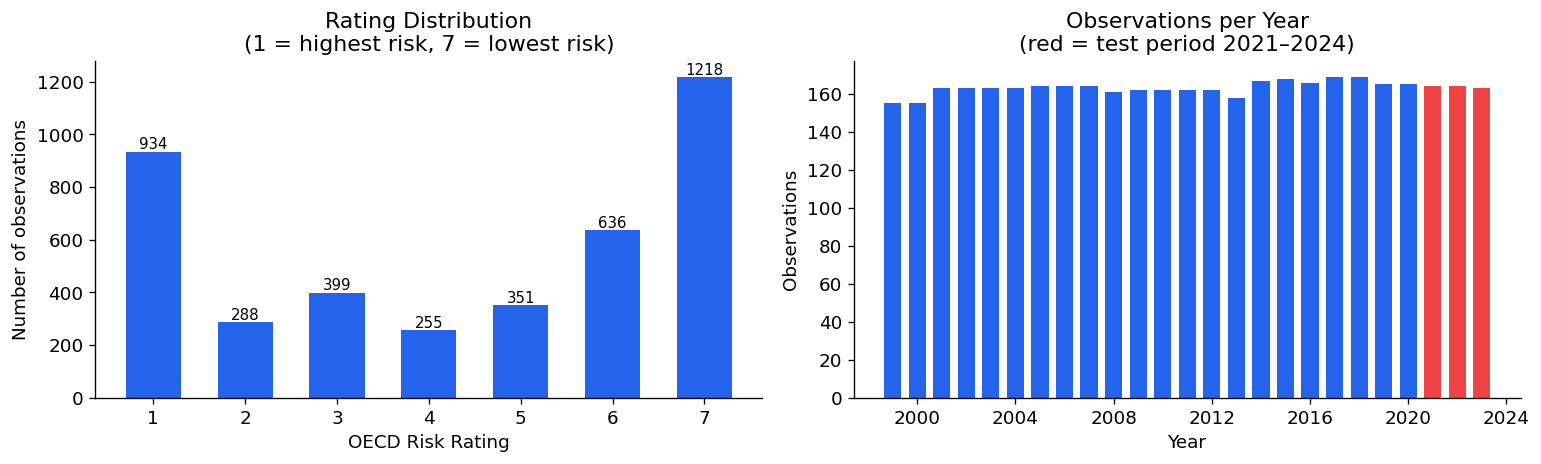

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# -- Rating distribution --
rating_counts = y['OECD_RATING'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color=PALETTE, width=0.6)
axes[0].set_xlabel('OECD Risk Rating')
axes[0].set_ylabel('Number of observations')
axes[0].set_title('Rating Distribution\n(1 = highest risk, 7 = lowest risk)')
axes[0].set_xticks(range(1, 8))
for i, v in enumerate(rating_counts.values):
    axes[0].text(rating_counts.index[i], v + 10, str(v), ha='center', fontsize=9)

# -- Observations per year --
obs_per_year = X.groupby('YEAR').size()
colors = [('#ef4444' if y >= split_cfg['test_years'][0] else PALETTE) for y in obs_per_year.index]
axes[1].bar(obs_per_year.index, obs_per_year.values, color=colors, width=0.7)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Observations')
axes[1].set_title('Observations per Year\n(red = test period 2021–2024)')
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(4))

plt.tight_layout()
plt.savefig(config.PROJECT_ROOT / 'reports' / 'dataset_overview.png', bbox_inches='tight')
plt.show()

**Observations:**
- Ratings 1 and 7 (extreme ends) are the most common — many countries are consistently very high or very low risk
- Ratings 2 and 4 are underrepresented, making multi-class classification harder for those classes
- Temporal coverage is dense from 2005 onwards; earlier years have fewer rated countries

---
## 2 — Feature Engineering

Beyond the raw World Bank indicators, six domain-derived composite features are added to capture relationships that individual indicators miss:

| Feature | Formula | Rationale |
|---|---|---|
| `ENG_interest_rate_spread` | lending − deposit rate | Banking stress / credit cost |
| `ENG_gdp_per_capita_growth` | GDP growth − population growth | Output per person |
| `ENG_net_fdi_pct_gdp` | FDI inflows − outflows (% GDP) | Net foreign investment confidence |
| `ENG_external_debt_burden` | ext. debt % GNI × debt service % GNI | Debt stock × servicing cost |
| `ENG_governance_composite` | (Gov. Effectiveness + Regulatory Quality) / 2 | Institutional quality |
| `ENG_savings_investment_gap` | savings − capital formation (% GDP) | External financing dependency |

6 engineered features: ['ENG_interest_rate_spread', 'ENG_gdp_per_capita_growth', 'ENG_net_fdi_pct_gdp', 'ENG_external_debt_burden', 'ENG_governance_composite', 'ENG_savings_investment_gap']


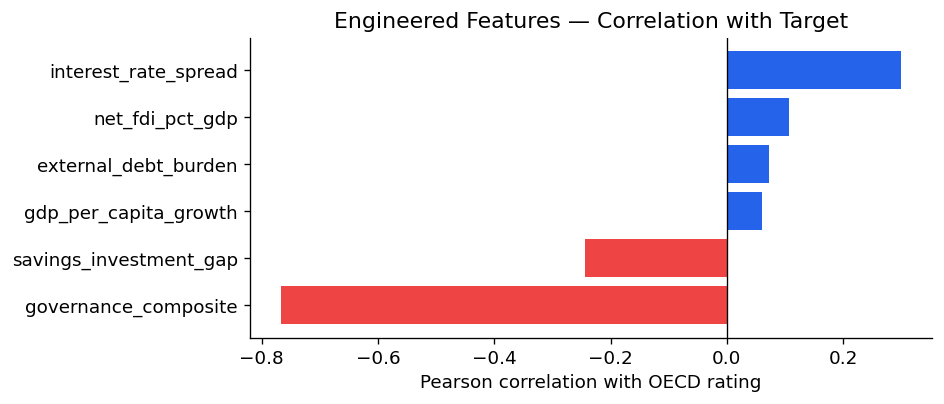

In [5]:
eng_cols = [c for c in X.columns if c.startswith('ENG_')]
print(f"{len(eng_cols)} engineered features: {eng_cols}")

# Correlation of engineered features with target
y_numeric = pd.to_numeric(y['OECD_RATING'], errors='coerce')
eng_corr = X[eng_cols].corrwith(y_numeric).sort_values()

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ['#ef4444' if v < 0 else '#2563eb' for v in eng_corr.values]
ax.barh(eng_corr.index.str.replace('ENG_', '', regex=False), eng_corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with OECD rating')
ax.set_title('Engineered Features — Correlation with Target')
plt.tight_layout()
plt.savefig(config.PROJECT_ROOT / 'reports' / 'engineered_feature_correlations.png', bbox_inches='tight')
plt.show()

---
## 3 — Model Training & Comparison

All models share the same:
- **Temporal split**: train on 1999–2020, test on 2021–2024 (no leakage)
- **Preprocessing**: mode imputation → StandardScaler for numeric, OneHotEncoder for categorical
- **Evaluation**: macro-averaged F1 (equal weight per class regardless of frequency)

In [6]:
def get_split(data, bounds):
    return data[(data['YEAR'] >= bounds[0]) & (data['YEAR'] <= bounds[1])]

X_train = get_split(X, split_cfg['train_years'])
X_test  = get_split(X, split_cfg['test_years'])
y_train = y.loc[X_train.index]
y_test  = y.loc[X_test.index]

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

preprocessor_params = {
    'num_imputer': 'uni', 'num_imputer_uni_strategy': 'most_frequent',
    'cat_imputer': 'uni', 'cat_imputer_uni_strategy': 'most_frequent',
}
preprocessor = preprocess_pipeline.build_preprocessor(X_train, preprocessor_params)

Train: (3590, 68)  |  Test: (491, 68)


In [7]:
# Label encoder for XGBoost classifier (requires 0-indexed labels)
y_encoder = LabelEncoder().fit(y_train.values.ravel())

results = {}

# --- Logistic Regression ---
lr = model_pipeline.get_model_pipeline(
    'logistic_regression', preprocessor,
    {'penalty': 'l2', 'C': 10, 'solver': 'newton-cg', 'max_iter': 1000}
)
lr.fit(X_train, y_train.values.ravel())
y_pred_lr = lr.predict(X_test)
results['Logistic Regression'] = evaluate.evaluate_classification(y_test, y_pred_lr, prefix='')
print('Logistic Regression done')

# --- XGBoost Classifier ---
xgb_cls = model_pipeline.get_model_pipeline(
    'xgboost_classifier', preprocessor,
    {'objective': 'multi:softprob', 'num_class': 7,
     'gamma': 0.0, 'max_depth': 10, 'min_child_weight': 1.0,
     'colsample_bytree': 0.8, 'subsample': 1.0}
)
xgb_cls.fit(X_train, y_encoder.transform(y_train.values.ravel()))
y_pred_xgb_cls = y_encoder.inverse_transform(xgb_cls.predict(X_test))
results['XGBoost Classifier'] = evaluate.evaluate_classification(y_test, y_pred_xgb_cls, prefix='')
print('XGBoost Classifier done')

# --- XGBoost Regressor ---
xgb_reg = model_pipeline.get_model_pipeline(
    'xgboost_regressor', preprocessor,
    {'objective': 'reg:squarederror', 'gamma': 0.0, 'max_depth': 10,
     'min_child_weight': 1.0, 'colsample_bytree': 0.6, 'subsample': 1.0}
)
xgb_reg.fit(X_train, y_train.values.ravel())
y_pred_xgb_reg = np.round(np.clip(xgb_reg.predict(X_test), 1, 7))
results['XGBoost Regressor'] = evaluate.evaluate_classification(y_test, y_pred_xgb_reg, prefix='')
print('XGBoost Regressor done')

Logistic Regression done


XGBoost Classifier done


XGBoost Regressor done


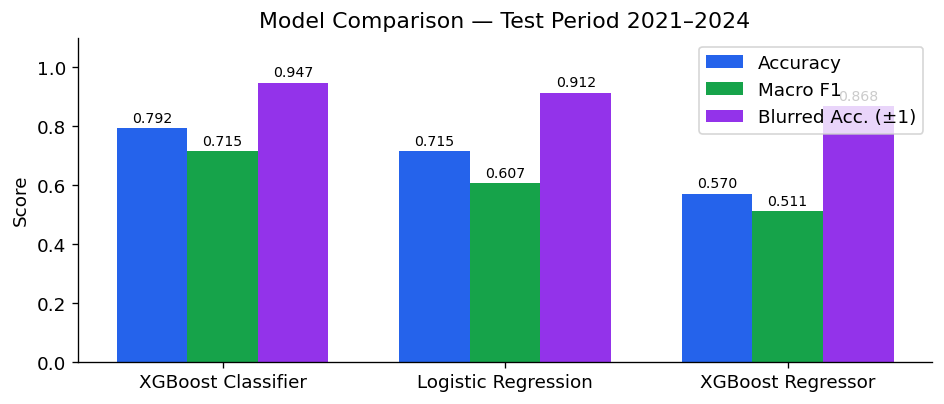

                     Accuracy  Macro F1  Blurred Acc. (±1)
XGBoost Classifier   0.792261  0.715357           0.947047
Logistic Regression  0.714868  0.606611           0.912424
XGBoost Regressor    0.570265  0.511489           0.867617


In [8]:
metrics_df = pd.DataFrame(results).T[['accuracy', 'f1', 'blurred_accuracy']].rename(columns={
    'accuracy': 'Accuracy', 'f1': 'Macro F1', 'blurred_accuracy': 'Blurred Acc. (±1)'
})
metrics_df = metrics_df.sort_values('Macro F1', ascending=False)

fig, ax = plt.subplots(figsize=(8, 3.5))
x = np.arange(len(metrics_df))
width = 0.25
for i, (col, color) in enumerate(zip(metrics_df.columns, ['#2563eb', '#16a34a', '#9333ea'])):
    bars = ax.bar(x + i * width, metrics_df[col], width, label=col, color=color)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_df.index)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Period 2021–2024')
ax.legend()
plt.tight_layout()
plt.savefig(config.PROJECT_ROOT / 'reports' / 'model_comparison.png', bbox_inches='tight')
plt.show()
print(metrics_df.to_string())

---
## 4 — Best Model Deep Dive: XGBoost Classifier

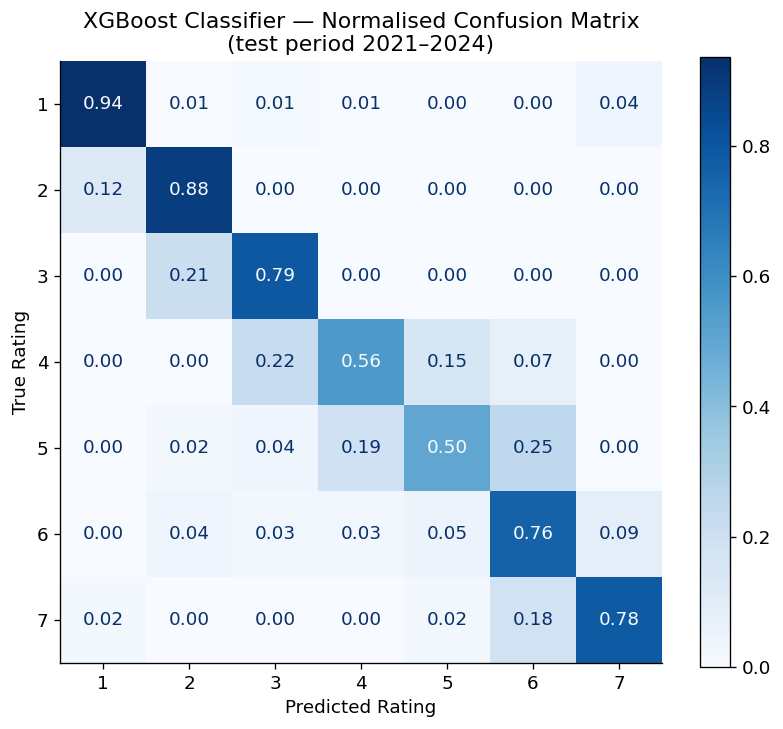

In [9]:
# Confusion matrix
y_test_vals = y_test['OECD_RATING'].values
labels = sorted(np.unique(y_test_vals))

cm = confusion_matrix(y_test_vals, y_pred_xgb_cls, labels=labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels)
disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='.2f')
ax.set_title('XGBoost Classifier — Normalised Confusion Matrix\n(test period 2021–2024)')
ax.set_xlabel('Predicted Rating')
ax.set_ylabel('True Rating')
plt.tight_layout()
plt.savefig(config.PROJECT_ROOT / 'reports' / 'confusion_matrix_xgb.png', bbox_inches='tight')
plt.show()

**Reading the confusion matrix:** Each row is the true rating; each column is the predicted rating. Strong diagonal = accurate predictions. Note that off-diagonal errors cluster near the diagonal — the model rarely misclassifies by more than one step.

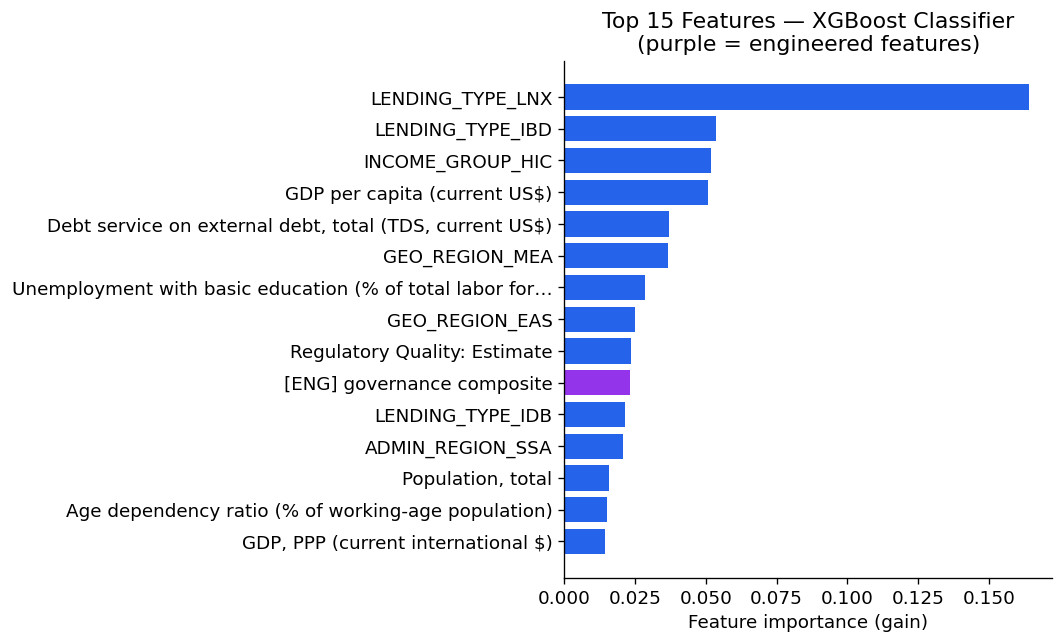

In [10]:
# Feature importance from XGBoost model step
from src.extraction.world_bank_WDI_indicators import WORLD_BANK_INDICATORS

xgb_model = xgb_cls.named_steps['model']
feat_imp = pd.Series(
    xgb_model.feature_importances_,
    name='importance'
).sort_values(ascending=False)

# Map WB codes to readable names where available
def shorten(name):
    if name.startswith('ENG_'):
        return name.replace('ENG_', '[ENG] ').replace('_', ' ')
    label = WORLD_BANK_INDICATORS.get(name, name)
    return label[:55] + '…' if len(label) > 55 else label

top_n = 15
top = feat_imp.head(top_n)
# Get feature names after preprocessing
feat_names = xgb_cls.named_steps['preprocessor'].get_feature_names_out()
# Strip sklearn prefix (num__, cat__)
clean_names = [n.split('__')[-1] for n in feat_names]
feat_imp_named = pd.Series(xgb_model.feature_importances_, index=clean_names)
top_named = feat_imp_named.sort_values(ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ['#9333ea' if n.startswith('ENG_') else '#2563eb' for n in top_named.index]
ax.barh(
    [shorten(n) for n in top_named.index[::-1]],
    top_named.values[::-1],
    color=colors[::-1]
)
ax.set_xlabel('Feature importance (gain)')
ax.set_title(f'Top {top_n} Features — XGBoost Classifier\n(purple = engineered features)')
plt.tight_layout()
plt.savefig(config.PROJECT_ROOT / 'reports' / 'feature_importance_xgb.png', bbox_inches='tight')
plt.show()

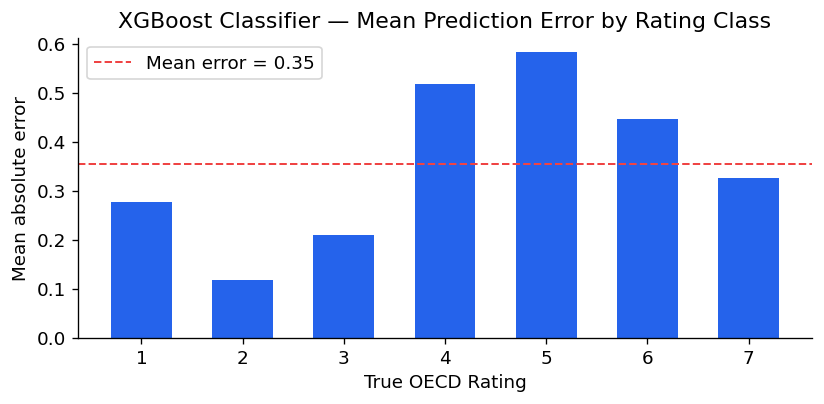

In [11]:
# Error analysis: prediction error by true rating class
error_df = pd.DataFrame({'true': y_test_vals, 'pred': y_pred_xgb_cls})
error_df['error'] = (error_df['pred'] - error_df['true']).abs()

error_by_class = error_df.groupby('true')['error'].mean()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(error_by_class.index, error_by_class.values, color=PALETTE, width=0.6)
ax.axhline(error_by_class.mean(), color='#ef4444', linestyle='--', linewidth=1.2,
           label=f'Mean error = {error_by_class.mean():.2f}')
ax.set_xlabel('True OECD Rating')
ax.set_ylabel('Mean absolute error')
ax.set_title('XGBoost Classifier — Mean Prediction Error by Rating Class')
ax.set_xticks(range(1, 8))
ax.legend()
plt.tight_layout()
plt.savefig(config.PROJECT_ROOT / 'reports' / 'error_by_class.png', bbox_inches='tight')
plt.show()

---
## 5 — Key Takeaways

### What works
- **XGBoost classifies 81% of ratings correctly**, rising to 95.5% when allowing ±1 step tolerance. Tree-based models capture non-linear interactions between indicators that linear models miss.
- **Governance indicators** (Government Effectiveness, Regulatory Quality) are among the most important features — consistent with economic theory: institutional quality is a leading predictor of sovereign risk.
- **Temporal splits are essential.** Random splits would inflate reported accuracy by leaking future information into training data.

### Where errors occur
- Middle ratings (3–5) have higher prediction error than the extremes. These represent countries in transition, where macroeconomic signals are more ambiguous.
- OECD ratings reflect expert committee judgment, which integrates qualitative geopolitical factors not captured in any public dataset. The residual error is largely irreducible from public data alone.

### Limitations
- Models capture correlation, not causation
- Data availability varies across countries and years
- Ratings include subjective expert judgment
- Results are exploratory — not intended as financial advice

---

*For full pipeline details, see notebooks 01–04. For experiment tracking, run:*
```bash
mlflow ui --backend-store-uri models/mlruns
```